In [90]:
import warnings
warnings.filterwarnings("ignore")

`Region` - Субъект РФ

`Wages` - Среднемесячная номинальная начисленная заработная плата работников организаций в 2021 году, руб.

`HighEdu` - Удельный вес занятого населения с высшим образованием в 2021 году, %

`SecEdu` - Удельный вес занятого населения со средним профессиональным образованием в 2021 году, %

`SecStudent` - Численность студентов, обучающихся по программам подготовки специалистов среднего звена на 10000 человек населения, 2021-2022 год обучения

`HighStudent` - Численность студентов, обучающихся по программам бакалавриата, специалитета, магистратуры на 10000 человек населения, 2021-2022 год обучения

`University` - Число организаций и филиалов организаций высшего образования в 2021 году

`Popul` - Среднегодовая численность населения в 2021 году, тыс. чел.

`WorkAge` - Численность населения в трудоспособном возрасте в 2021 году, тыс. чел.

In [641]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, make_scorer
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [12]:
df = pd.read_excel("dataReg.xlsx")

In [13]:
df

,Region,Wages,HighEdu,SecEdu,SecStudent,HighStudent,University,Popul,WorkAge
0,Алтайский край,33872,27.8,46.2,185,225,17,2282.3,1262.11
1,Амурская область,59098,27.4,48.3,238,185,6,777.2,455.44
2,Архангельская область,57979,27.3,56.4,179,161,7,1076.2,603.75
3,Астраханская область,42096,35.3,45.0,251,287,13,993.6,558.40
4,Белгородская область,41775,33.7,49.8,206,304,11,1536.6,874.33
...,...,...,...,...,...,...,...,...,...
80,Чеченская Республика,31291,39.2,32.6,183,222,4,1507.2,866.64
81,Чувашская Республика,35799,31.8,45.2,214,287,10,1203.2,681.01
82,Чукотский автономный округ,130738,36.5,54.8,140,19,1,49.8,31.87
83,Ямало-Ненецкий автономный округ,116376,44.9,40.3,153,4,1,549.6,353.94


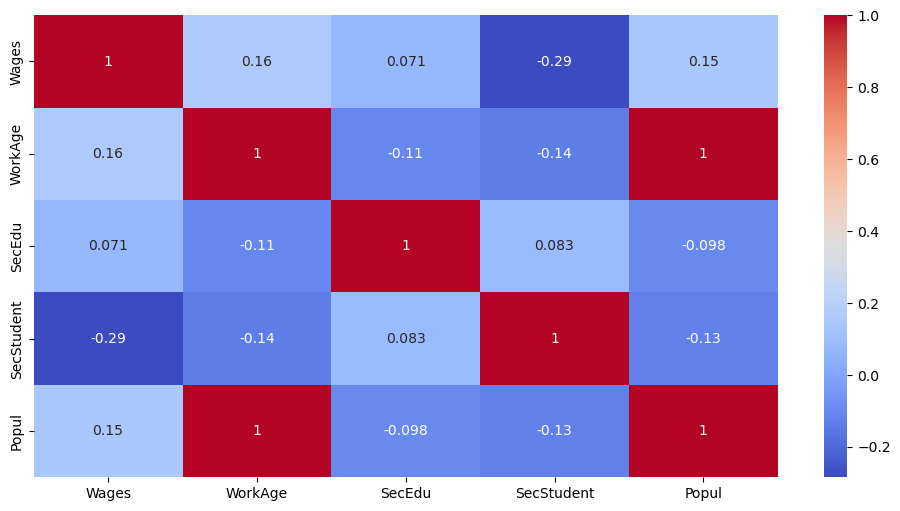

In [668]:
plt.figure(figsize=(12, 6))
sns.heatmap(df[["Wages", "WorkAge", "SecEdu", "SecStudent", "Popul"]].corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Корреляция SecStudent с Wages: -0.29 (слабая отрицательная связь)

Корреляция SecStudent с WorkAge: -0.14 (слабая отрицательная связь)

Корреляция SecStudent с SecEdu: 0.083 (очень слабая положительная связь)

Это нам говорит об отсутствии выраженной линейной зависимости

# Task 1

Можно ли утверждать, что численность студентов среднего образования статистически значимо зависит от следующих показателей:
Средней начисленной заработной платы; Численностью работоспособного населения; Удельный вес занятого населения со средним профессиональным образованием. Выбрать метод МО, позволяющий ответить на данный вопрос, оценить модель, обосновать ответ используя статистические показатели. Можно ли использовать показатель "численность населения"?

In [615]:
scaler = StandardScaler()

X = df.iloc[:, 1:].copy()
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(
    X_std,
    columns=X.columns,
    index=X.index
)

In [621]:
formula = "SecStudent ~ Wages + WorkAge + SecEdu"
model = smf.ols(formula, data=X_std).fit()

In [623]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             SecStudent   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     2.958
Date:                Thu, 05 Mar 2026   Prob (F-statistic):             0.0372
Time:                        20:52:19   Log-Likelihood:                -116.19
No. Observations:                  85   AIC:                             240.4
Df Residuals:                      81   BIC:                             250.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.874e-16      0.105  -1.78e-15      1.0

==============================================================================

**Используем регрессионный анализ для первого пункта задачи (OLS). С оценкой по p-values и F‑статистике.**

Коэффициенты:

    Wages: coef = –0.2783 (p = 0.011) < 0.05 – статистически значим на уровне 5%. Отрицательная, но довольно слабая связь.

    WorkAge: coef = –0.0840 (p = 0.437) > 0.05 – не значим.

    SecEdu: coef = 0.0937 (p = 0.382) > 0.05 – не значим.

**Модель в свою очередь, оценивая метрику R-squared - 0.099, плохо объясняет данные. Но все таки по показателю Prob (F-statistic) - 0.0372, модель статистически важна**

`Нет, мы не можем утверждать, что что численность студентов среднего профессионального образования статистически значимо зависит от: средней заработной платы; численности трудоспособного населения; доли занятых со средним профессиональным образованием.`

Только один фактор Wages показал статистическую значимость, но его влияние очень слабое. 

Можно ли использовать показатель "численность населения"?
Использовать Popul вместе с WorkAge нельзя полной линейной зависимости.

# ======================================================================================================================================================

# Task 2

Можно ли утверждать, что  города федерального значения отличаются от других регионов РФ?. Выбрать метод МО, позволяющий ответить на данный вопрос, оценить, обосновать ответ . 

## Классификация деревом решений

In [521]:
target = np.zeros(85)
target[10] = 1 # г. Москва
target[11] = 1 # г. Санкт-Петербург
target[12] = 1 # г. Севастополь
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [533]:
dtcN = DecisionTreeClassifier(
    criterion = "gini",
    max_depth = 34,
    min_samples_split = 2,
    min_samples_leaf = 1, 
    random_state=1
)
dtcN.fit(df.iloc[:, 1:], target)

DecisionTreeClassifier(max_depth=34, random_state=1)

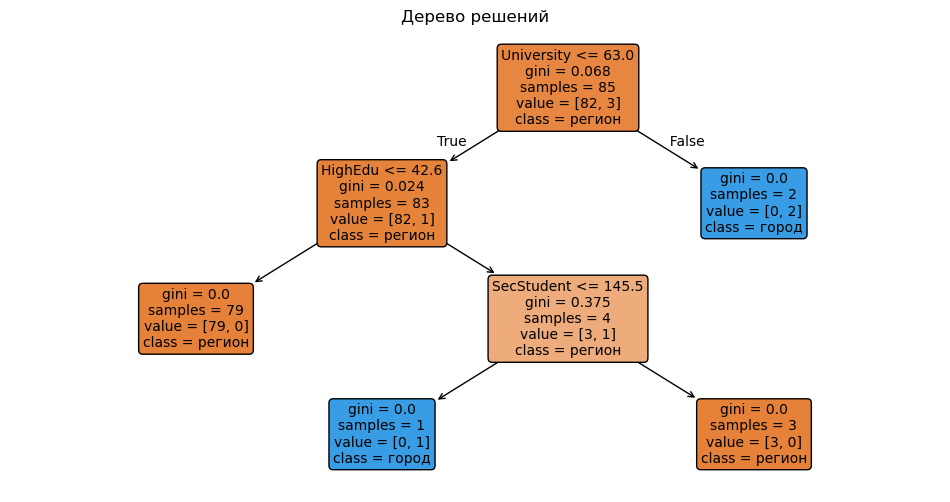

In [535]:
plt.figure(figsize=(12, 6))
plot_tree(
    dtcN,
    feature_names=df.iloc[:, 1:].columns.tolist(),  # названия признаков
    class_names=['регион', 'город'],         # названия классов
    filled=True,                             # раскрашивает узлы
    rounded=True,                            # закругленные углы
    fontsize=10,
    max_depth=3,
)
plt.title('Дерево решений')
plt.show()

In [527]:
dtcN.score(df.iloc[:, 1:], target)

1.0

По оценке видим, что модель хорошо объясняет наши данные

In [542]:
avg_region = df[~df["Region"].isin(["г. Москва", "г. Санкт-Петербург", "г. Севастополь"])].describe().loc['mean'].round(1)
moscow = df[df["Region"] == "г. Москва"].iloc[0]
sankt = df[df["Region"] == "г. Санкт-Петербург"].iloc[0]
sevas = df[df["Region"] == "г. Севастополь"].iloc[0]

df_vs = pd.DataFrame({"Mean_Region": avg_region, "Moscow": moscow.iloc[1:], "Saint-Petersburg": sankt.iloc[1:], "Sevastopol": sevas.iloc[1:]})
df_vs

,Mean_Region,Moscow,Saint-Petersburg,Sevastopol
Wages,48664.6,112768,76259,40145
HighEdu,32.3,51.8,43.8,42.7
SecEdu,45.9,41.0,42.7,44.3
SecStudent,202.2,142,174,138
HighStudent,219.9,601,587,268
University,12.4,146,67,6
Popul,1552.7,12645.3,5380.9,516.0
WorkAge,886.3,7308.98,3115.54,301.86


По визуализации дерева решений видим, что все конечные узлы чисты (значение примеси gini = 0.0), что говорит об идеальном разделении обучающей выборки.

Мы четко можем разделить ФЗ города по следующим правилам: 

- Москва и Питер:
    - Если число организаций и филиалов организаций высшего образования(`University`) больше 63. То мы говорим, что это точно город федерального значения.
- Севастополь:
    - Если число организаций и филиалов организаций высшего образования(`University`) меньше 63. Удельный вес занятого населения с высшим образованием в 2021 году, % (`HighEdu`) больше 42.6. Численность студентов, обучающихся по программам подготовки специалистов среднего звена на 10000 человек населения, 2021-2022 год обучения (`SecStudent`) меньше 145.5. То мы тоже говорим, что этот город ФЗ

In [565]:
df[df["University"]> 63] # города, в которых University > 63. Два наших ФЗ 

,Region,Wages,HighEdu,SecEdu,SecStudent,HighStudent,University,Popul,WorkAge
10,г. Москва,112768,51.8,41.0,142,601,146,12645.3,7308.98
11,г. Санкт-Петербург,76259,43.8,42.7,174,587,67,5380.9,3115.54


In [583]:
df[(df["University"] < 63) & (df["HighEdu"] > 42.6) & (df["SecStudent"] < 145.5)] # городa, в которых University < 63 and HighEdu > 42.6 and SecStudent < 145.5. Один наш ФЗ город

,Region,Wages,HighEdu,SecEdu,SecStudent,HighStudent,University,Popul,WorkAge
12,г. Севастополь,40145,42.7,44.3,138,268,6,516.0,301.86


In [585]:
dtcN.feature_importances_

array([0.        , 0.08221912, 0.        , 0.25914634, 0.        ,
       0.65863454, 0.        , 0.        ])

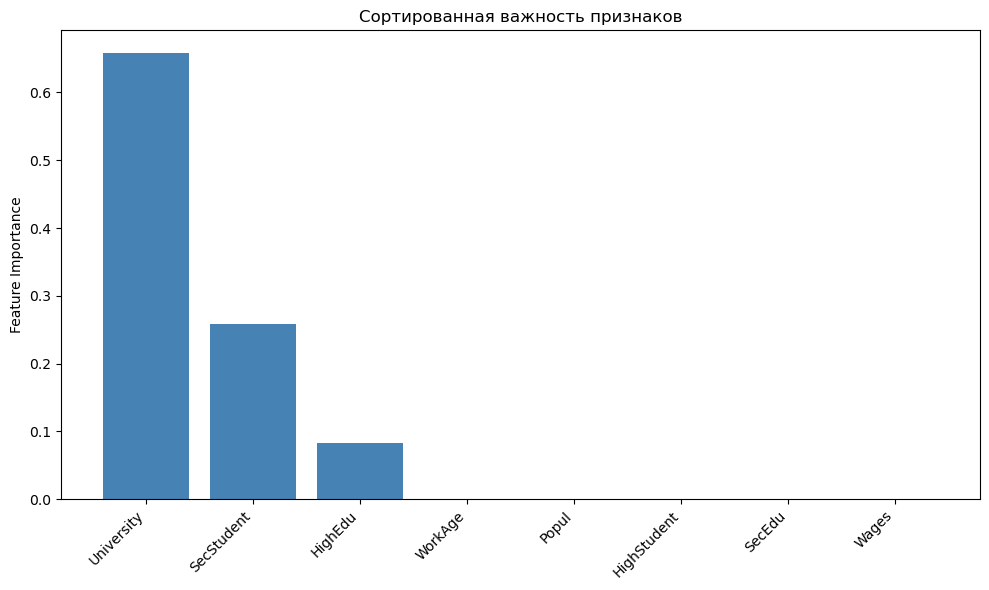

In [587]:
features = df.iloc[:, 1:].columns.tolist()  # имена признаков
importances = dtcN.feature_importances_

# Сортировка: индексы по убыванию важности
indices = np.argsort(importances)[::-1]

# Сортированные значения и имена
sorted_importances = importances[indices]
sorted_features = [features[i] for i in indices]

# Гистограмма (bar plot)
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_features)), sorted_importances, color='steelblue')
plt.xticks(range(len(sorted_features)), sorted_features, rotation=45, ha='right')
plt.ylabel('Feature Importance')
plt.title('Сортированная важность признаков')
plt.tight_layout()
plt.show()

Можно ли утверждать, что города федерального значения отличаются от других регионов РФ? 

`Да, мы можем это утверждать по приведенным выше доводам.`